# Pricing American Options by COS Method
**Work in progress** 

Goal use COS method for pricing American options

In [6]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import norm
from scipy.integrate import trapezoid

In [7]:
def european_put_bs(S0, K, r, sigma, T):
    """Black-Scholes European put"""
    if T <= 0:
        return max(K - S0, 0)
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)


def binomial_american_put(S0, K, r, sigma, T, N=200):
    """Binomial tree American put (reference)"""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    
    # Asset prices at maturity
    S = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])
    
    # Option values at maturity
    V = np.maximum(K - S, 0)
    
    # Backward induction
    for j in range(N-1, -1, -1):
        for i in range(j+1):
            S_current = S0 * (u**(j-i)) * (d**i)
            exercise = max(K - S_current, 0)
            continuation = np.exp(-r*dt) * (p*V[i] + (1-p)*V[i+1])
            V[i] = max(exercise, continuation)
    
    return V[0]

In [8]:
def cos_american_put(S0, K, r, sigma, T, N=128, M=50):
    """
    COS method for American put - Algorithm 3 from Fang & Oosterlee (2009)
    
    Based on "Pricing early-exercise and discrete barrier options by 
    Fourier-cosine series expansions", Numerische Mathematik 114(1):27-62
    
    This implements the grid reconstruction approach where at each timestep we:
    1. Apply characteristic function to V_k to get continuation value coefficients
    2. Reconstruct continuation value on spatial grid
    3. Apply early exercise: max(continuation, intrinsic)
    4. Project back to Fourier space for next iteration
    
    Args:
        S0: Initial stock price
        K: Strike price
        r: Risk-free rate
        sigma: Volatility
        T: Time to maturity
        N: Number of Fourier terms (default 128)
        M: Number of exercise dates (default 50)
    
    Returns:
        American put option price
    """
    # Transform to log-moneyness x = ln(S/K)
    x0 = np.log(S0 / K)
    dt = T / M
    
    # Determine integration range [a,b]
    L = 10
    mu = r - 0.5 * sigma**2
    c1 = mu * T
    c2 = sigma**2 * T
    
    a = c1 - L * np.sqrt(c2)
    b = c1 + L * np.sqrt(c2)
    
    # Wavevector
    k = np.arange(N)
    omega_k = k * np.pi / (b - a)
    
    # Characteristic function for one timestep dt
    phi = np.exp(1j * omega_k * mu * dt - 0.5 * sigma**2 * omega_k**2 * dt)
    
    # Payoff coefficients for put option
    def compute_payoff_coefficients():
        """Put payoff: v(x) = max(1 - exp(x), 0), active on [a, 0]"""
        c, d = a, min(0.0, b)
        
        # Chi function - Eq. (26)
        chi = np.zeros(N)
        chi[0] = d - c
        chi[1:] = (np.sin(omega_k[1:] * (d - a)) - np.sin(omega_k[1:] * (c - a))) / omega_k[1:]
        
        # Psi function - Eq. (27)
        psi = np.zeros(N)
        psi[0] = (d - c) - (np.exp(d) - np.exp(c))
        
        for k_idx in range(1, N):
            omega = omega_k[k_idx]
            term_d = np.exp(d) * (np.cos(omega * (d - a)) + omega * np.sin(omega * (d - a)))
            term_c = np.exp(c) * (np.cos(omega * (c - a)) + omega * np.sin(omega * (c - a)))
            psi[k_idx] = (term_d - term_c) / (1.0 + omega**2)
        
        return (2.0 / (b - a)) * (chi - psi)
    
    # Initialize at maturity
    V_k = compute_payoff_coefficients()
    
    # Discount factor
    discount = np.exp(-r * dt)
    
    # Grid for reconstruction
    n_grid = 4096
    x_grid = np.linspace(a, b, n_grid)
    
    # Precompute cosine matrix
    cos_matrix = np.cos(np.outer(k, x_grid - a) * np.pi / (b - a))
    
    # Exercise value
    g_grid = np.maximum(1.0 - np.exp(x_grid), 0.0)
    
    # Weights for Fourier sum
    weights = np.ones(N)
    weights[0] = 0.5
    
    # Backward induction: from t_M to t_1
    for m in range(M - 1, 0, -1):
        # Apply characteristic function
        C_k = phi * V_k
        C_k_real = np.real(C_k)
        
        # Reconstruct continuation value
        v_cont = (C_k_real * weights) @ cos_matrix
        
        # Apply early exercise
        v_american = np.maximum(discount * v_cont, g_grid)
        
        # Project back to Fourier space using trapezoidal integration
        for k_idx in range(N):
            V_k[k_idx] = (2.0 / (b - a)) * trapezoid(v_american * cos_matrix[k_idx], x_grid)
    
    # Final step: from t_1 to t_0
    C_k_final = phi * V_k
    C_k_real = np.real(C_k_final)
    
    # Evaluate at x0
    cos_x0 = np.cos(k * np.pi * (x0 - a) / (b - a))
    value = np.sum(C_k_real * weights * cos_x0)
    value *= discount
    
    return value * K


def cos_american_call(S0, K, r, sigma, T, N=128, M=50):
    """
    COS method for American call - Algorithm 3 from Fang & Oosterlee (2009)
    
    Args:
        S0: Initial stock price
        K: Strike price
        r: Risk-free rate
        sigma: Volatility
        T: Time to maturity
        N: Number of Fourier terms (default 128)
        M: Number of exercise dates (default 50)
    
    Returns:
        American call option price
    """
    # Transform to log-moneyness x = ln(S/K)
    x0 = np.log(S0 / K)
    dt = T / M
    
    # Determine integration range [a,b] using cumulants
    L = 10
    mu = r - 0.5 * sigma**2
    c1 = mu * dt
    c2 = sigma**2 * dt
    
    a = c1 - L * np.sqrt(c2)
    b = c1 + L * np.sqrt(c2)
    
    # Wavevector
    k = np.arange(N)
    omega_k = k * np.pi / (b - a)
    
    # Characteristic function for GBM
    phi = np.exp(1j * omega_k * mu * dt - 0.5 * sigma**2 * omega_k**2 * dt)
    
    # Chi and Psi functions for call option payoff
    def chi_func(c, d, k_arr):
        """Chi function: Eq. (26) from paper"""
        omega = k_arr * np.pi / (b - a)
        chi = np.zeros(len(k_arr))
        chi[0] = d - c
        idx = k_arr > 0
        chi[idx] = (np.sin(omega[idx] * (d - a)) - np.sin(omega[idx] * (c - a))) / omega[idx]
        return chi
    
    def psi_func(c, d, k_arr):
        """Psi function: Eq. (27) from paper"""
        omega = k_arr * np.pi / (b - a)
        psi = np.zeros(len(k_arr), dtype=complex)
        
        # k=0 case
        psi[0] = d - c
        
        # k>0 cases
        idx = k_arr > 0
        omega_pos = omega[idx]
        
        exp_d = np.exp(d)
        exp_c = np.exp(c)
        cos_d = np.cos(omega_pos * (d - a))
        cos_c = np.cos(omega_pos * (c - a))
        sin_d = np.sin(omega_pos * (d - a))
        sin_c = np.sin(omega_pos * (c - a))
        
        psi[idx] = (exp_d * (cos_d + omega_pos * sin_d) - 
                    exp_c * (cos_c + omega_pos * sin_c)) / (1.0 + omega_pos**2)
        
        return np.real(psi)
    
    # Initialize V_k at maturity for call option: max(exp(x) - 1, 0)
    # For call: payoff is nonzero for x in [0, b]
    c_call, d_call = 0.0, b
    chi_k = chi_func(c_call, d_call, k)
    psi_k = psi_func(c_call, d_call, k)
    
    V_k = (2.0 / (b - a)) * (psi_k - chi_k)
    
    # Pre-compute discount factor
    discount = np.exp(-r * dt)
    
    # Backward induction through exercise dates
    for m in range(M - 1, 0, -1):
        # Compute continuation value coefficients
        C_k = phi * V_k
        
        # Create dense grid for pointwise comparison
        n_grid = max(2048, 4 * N)
        x_grid = np.linspace(a, b, n_grid)
        
        # Reconstruct continuation value on grid
        cos_matrix = np.cos(np.outer(k, x_grid - a) * np.pi / (b - a))
        weights = np.ones(N)
        weights[0] = 0.5
        
        C_k_real = np.real(C_k)
        v_cont = (C_k_real * weights) @ cos_matrix
        
        # Exercise value on grid: g(x) = max(exp(x) - 1, 0)
        g_grid = np.maximum(np.exp(x_grid) - 1.0, 0.0)
        
        # American value: max(discounted continuation, exercise)
        v_american = np.maximum(discount * v_cont, g_grid)
        
        # Project back to Fourier space
        for k_idx in range(N):
            cos_k = np.cos(k_idx * np.pi * (x_grid - a) / (b - a))
            V_k[k_idx] = (2.0 / (b - a)) * trapezoid(v_american * cos_k, x_grid)
    
    # Final valuation at t=0
    C_k_final = phi * V_k
    C_k_real = np.real(C_k_final)
    
    cos_final = np.cos(k * np.pi * (x0 - a) / (b - a))
    weights_final = np.ones(N)
    weights_final[0] = 0.5
    
    value = np.sum(C_k_real * weights_final * cos_final)
    value *= discount
    
    return value * K




In [9]:
# Test the implementation
def test_american_put():
    """Test COS method vs binomial tree"""
    print("=== American Put Option Test ===")
    
    # Test parameters
    S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
    
    print(f"Parameters: S0={S0}, K={K}, r={r:.3f}, sigma={sigma:.3f}, T={T}")
    print("-" * 60)
    
    # European put
    euro_put = european_put_bs(S0, K, r, sigma, T)
    print(f"European Put (BS):        ${euro_put:.4f}")
    
    # Binomial American put (reference)
    start = time.time()
    binom_put = binomial_american_put(S0, K, r, sigma, T, N=200)
    binom_time = (time.time() - start) * 1000
    print(f"American Put (Binomial):  ${binom_put:.4f} ({binom_time:.1f} ms)")
    
    # COS American put
    start = time.time()
    cos_put = cos_american_put(S0, K, r, sigma, T, N=128, M=100)
    cos_time = (time.time() - start) * 1000
    print(f"American Put (COS):       ${cos_put:.4f} ({cos_time:.1f} ms)")
    
    # Analysis
    early_premium = binom_put - euro_put
    cos_error = abs(cos_put - binom_put)
    print(f"\nEarly exercise premium:   ${early_premium:.4f}")
    print(f"COS error vs Binomial:    ${cos_error:.4f} ({cos_error/binom_put*100:.2f}%)")
    
    # Test multiple parameter sets
    print("\n=== Extended Tests ===")
    test_cases = [
        (90, 100, 0.05, 0.2, 1.0, "OTM Put"),
        (100, 100, 0.05, 0.2, 1.0, "ATM Put"),
        (110, 100, 0.05, 0.2, 1.0, "ITM Put"),
        (100, 100, 0.05, 0.3, 1.0, "High Vol"),
        (100, 100, 0.05, 0.2, 0.5, "Short Maturity"),
    ]
    
    print(f"{'Case':<15} {'Binomial':>10} {'COS':>10} {'Error':>10} {'Error %':>10}")
    print("-" * 60)
    
    for S0, K, r, sigma, T, label in test_cases:
        binom = binomial_american_put(S0, K, r, sigma, T, N=200)
        cos_val = cos_american_put(S0, K, r, sigma, T, N=128, M=50)
        error = abs(cos_val - binom)
        error_pct = error / binom * 100 if binom > 0 else 0
        print(f"{label:<15} ${binom:>9.4f} ${cos_val:>9.4f} ${error:>9.4f} {error_pct:>9.2f}%")

# Run the test
test_american_put()

=== American Put Option Test ===
Parameters: S0=100, K=100, r=0.050, sigma=0.200, T=1.0
------------------------------------------------------------
European Put (BS):        $5.5735
American Put (Binomial):  $6.0864 (21.8 ms)
American Put (COS):       $6.9413 (226.4 ms)

Early exercise premium:   $0.5129
COS error vs Binomial:    $0.8549 (14.05%)

=== Extended Tests ===
Case              Binomial        COS      Error    Error %
------------------------------------------------------------
OTM Put         $  11.4945 $  12.3349 $   0.8404      7.31%
ATM Put         $   6.0864 $   6.9088 $   0.8224     13.51%
ITM Put         $   2.9917 $   3.5592 $   0.5675     18.97%
High Vol        $   9.8632 $   9.9223 $   0.0592      0.60%
Short Maturity  $   4.6525 $   8.7465 $   4.0940     88.00%


Computing option values for plot...


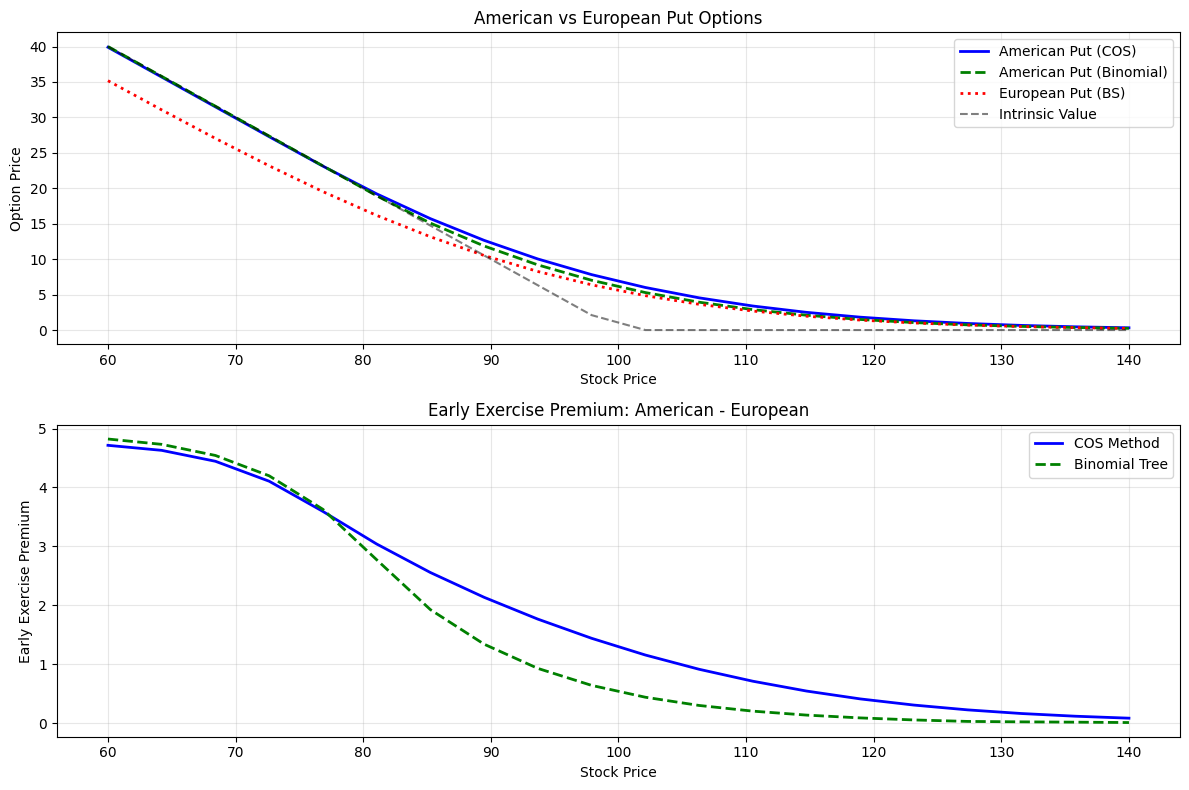

In [10]:
# Visualization
def plot_comparison():
    """Plot American vs European put values"""
    K, r, sigma, T = 100, 0.05, 0.2, 1.0
    S_range = np.linspace(60, 140, 20)
    
    american_prices = []
    european_prices = []
    binomial_prices = []
    
    print("Computing option values for plot...")
    for S in S_range:
        euro = european_put_bs(S, K, r, sigma, T)
        amer_cos = cos_american_put(S, K, r, sigma, T, N=64, M=30)
        amer_binom = binomial_american_put(S, K, r, sigma, T, N=100)
        
        european_prices.append(euro)
        american_prices.append(amer_cos)
        binomial_prices.append(amer_binom)
    
    plt.figure(figsize=(12, 8))
    
    # Option values comparison
    plt.subplot(2, 1, 1)
    plt.plot(S_range, american_prices, 'b-', linewidth=2, label='American Put (COS)')
    plt.plot(S_range, binomial_prices, 'g--', linewidth=2, label='American Put (Binomial)')
    plt.plot(S_range, european_prices, 'r:', linewidth=2, label='European Put (BS)')
    plt.plot(S_range, np.maximum(K - S_range, 0), 'k--', alpha=0.5, label='Intrinsic Value')
    plt.xlabel('Stock Price')
    plt.ylabel('Option Price')
    plt.title('American vs European Put Options')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Early exercise premium
    plt.subplot(2, 1, 2)
    premium_cos = np.array(american_prices) - np.array(european_prices)
    premium_binom = np.array(binomial_prices) - np.array(european_prices)
    plt.plot(S_range, premium_cos, 'b-', linewidth=2, label='COS Method')
    plt.plot(S_range, premium_binom, 'g--', linewidth=2, label='Binomial Tree')
    plt.xlabel('Stock Price')
    plt.ylabel('Early Exercise Premium')
    plt.title('Early Exercise Premium: American - European')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run visualization
plot_comparison()